In [4]:
import re
import pandas as pd

In [5]:
df_final = pd.read_csv('../data/filtered_H-AIRosettaMP.csv')

In [6]:
df_final.tail()

,task_name,language_name,code,target,set
10871,Conway's Game of Life,JavaScript,function GameOfLife () {\n \n\tthis.init = fun...,Human_written,JavaScript_from_Python
10872,Bitmap/Bézier curves/Cubic,JavaScript,function draw() {\n var canvas = document.g...,Human_written,JavaScript_from_Python
10873,Bioinformatics/Sequence mutation,JavaScript,// Basic set-up\nconst numBases = 250\nconst n...,Human_written,JavaScript_from_Python
10874,Add a variable to a class instance at runtime,JavaScript,"e = {} // generic object\ne.foo = 1\ne[""...",Human_written,JavaScript_from_Python
10875,21 game,JavaScript,"<!DOCTYPE html><html lang=""en"">\n \n<head>\n ...",Human_written,JavaScript_from_Python


In [7]:


def extract_features(code):
    lines = code.split('\n')
    total_lines = len(lines)
    
    # 1. Longitud total del código
    total_chars = len(code)
    
    # 2. Número de líneas
    num_lines = total_lines
    
    # 3. Líneas en blanco
    blank_lines = sum(1 for l in lines if l.strip() == '')
    ratio_blank = blank_lines / total_lines if total_lines > 0 else 0
    
    # 4. Longitud promedio de línea
    non_blank = [l for l in lines if l.strip() != '']
    avg_line_length = sum(len(l) for l in non_blank) / len(non_blank) if non_blank else 0
    
    # 5. Comentarios (funciona para Python, Java, JS, C++, C#)
    single_comments = len(re.findall(r'//.*', code))        # Java, JS, C++, C#
    hash_comments = len(re.findall(r'#.*', code))           # Python
    multi_comments = len(re.findall(r'/\*.*?\*/', code, re.DOTALL))  # /* */
    total_comments = single_comments + hash_comments + multi_comments
    ratio_comments = total_comments / total_lines if total_lines > 0 else 0
    
    # 6. Longitud promedio de identificadores
    identifiers = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]+\b', code)
    avg_identifier_length = sum(len(i) for i in identifiers) / len(identifiers) if identifiers else 0
    num_identifiers = len(identifiers)
    
    # 7. Número de funciones
    func_patterns = [
        r'\bdef\s+\w+',           # Python
        r'\bfunction\s+\w+',      # JavaScript
        r'\bvoid\s+\w+\s*\(',     # Java, C++, C#
        r'\bint\s+\w+\s*\(',      # Java, C++, C#
        r'\bstring\s+\w+\s*\(',   # C#
        r'\bpublic\s+\w+\s+\w+\s*\(',  # Java, C#
    ]
    num_functions = sum(len(re.findall(p, code, re.IGNORECASE)) for p in func_patterns)
    
    # 8. Número de loops
    num_loops = len(re.findall(r'\b(for|while)\b', code))
    
    # 9. Número de condicionales
    num_conditionals = len(re.findall(r'\b(if|else|elif|switch)\b', code))
    
    # 10. Número de strings
    strings = re.findall(r'"[^"]*"|\'[^\']*\'', code)
    num_strings = len(strings)
    avg_string_length = sum(len(s) for s in strings) / len(strings) if strings else 0
    
    # 11. Indentación promedio
    indentations = [len(l) - len(l.lstrip()) for l in lines if l.strip() != '']
    avg_indentation = sum(indentations) / len(indentations) if indentations else 0
    
    return {
        'total_chars': total_chars,
        'num_lines': num_lines,
        'blank_lines': blank_lines,
        'ratio_blank': ratio_blank,
        'avg_line_length': avg_line_length,
        'total_comments': total_comments,
        'ratio_comments': ratio_comments,
        'avg_identifier_length': avg_identifier_length,
        'num_identifiers': num_identifiers,
        'num_functions': num_functions,
        'num_loops': num_loops,
        'num_conditionals': num_conditionals,
        'num_strings': num_strings,
        'avg_string_length': avg_string_length,
        'avg_indentation': avg_indentation,
    }



In [8]:
# Aplicar a todo el dataframe
features_df = df_final['code'].apply(extract_features).apply(pd.Series)
features_df['target'] = df_final['target'].values

In [9]:
print(features_df.tail())
print(features_df.shape)

       total_chars  num_lines  blank_lines  ratio_blank  avg_line_length  \
10871       2007.0       99.0         10.0     0.101010        21.337079   
10872       1352.0       50.0          5.0     0.100000        28.844444   
10873       3842.0      157.0         21.0     0.133758        26.948529   
10874         85.0        3.0          0.0     0.000000        27.666667   
10875       4866.0      159.0         17.0     0.106918        33.035211   

       total_comments  ratio_comments  avg_identifier_length  num_identifiers  \
10871             0.0        0.000000               4.530387            181.0   
10872             4.0        0.080000               5.301887            106.0   
10873            16.0        0.101911               5.252900            431.0   
10874             2.0        0.666667               5.125000              8.0   
10875            16.0        0.100629               5.124535            538.0   

       num_functions  num_loops  num_conditionals  num_s

In [10]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Separar features y target
X = features_df.drop(columns=['target'])
y = features_df['target']

# Dividir en train y test (80/20 igual que en Gurioli et al.)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalar features (importante para SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar SVM
modelo = SVC(kernel='linear', random_state=42)
modelo.fit(X_train, y_train)

# Evaluar
y_pred = modelo.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.6733
               precision    recall  f1-score   support

 Ai_generated       0.67      1.00      0.80      1465
Human_written       0.00      0.00      0.00       711

     accuracy                           0.67      2176
    macro avg       0.34      0.50      0.40      2176
 weighted avg       0.45      0.67      0.54      2176



/Users/diegolira/Documents/RETO_TC3002B.201/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/diegolira/Documents/RETO_TC3002B.201/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/diegolira/Documents/RETO_TC3002B.201/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

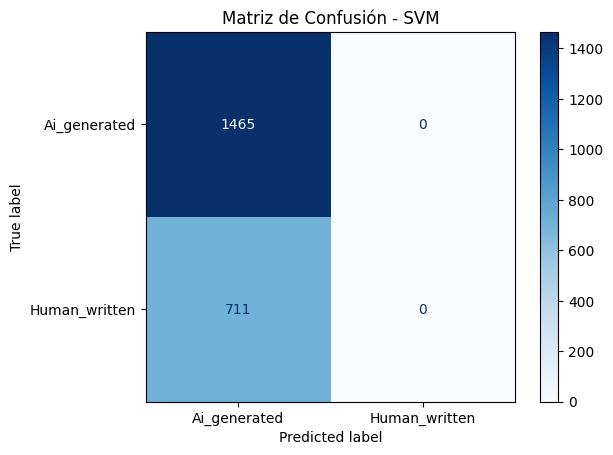

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcular matriz
cm = confusion_matrix(y_test, y_pred)

# Visualizarla
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - SVM')
plt.show()